# Data Analysis

Before beginning the evaluation of AI outputs, especially sentiments, we need to assess the quality of the datasets used by the chatbot. This step ensures that the data is clean, balanced and free from basic DQ issues that could negatively affect the AI's performance.

To perform this task, follow these steps:

- import Required Libraries for data analysis and manipulation
- read the provided datasets into appropriate data structures
- identify Issues in the Datasets: Duplicates, Imbalances, Completeness, Biases (mention type if possible), Relevance and Consistency
found issues should be visualized

It is a good practice to create reusable functions and methods to automate parts of this process. For example:

Functions to check for duplicates and remove them and etc.

By ensuring the datasets are clean and free from biases or inconsistencies, we can improve the reliability and accuracy of the AI's sentiment analysis and summary generation.

In [2]:
# Import required libraries
import pandas as pd
import numpy as np

In [3]:
movies_df = pd.read_csv('movies.csv')
users_df = pd.read_csv('users.csv')
users_reviews_df = pd.read_csv('users_reviews.csv')

print(f"\nMovies dataset: {movies_df.shape[0]} rows, {movies_df.shape[1]} columns")
print(f"Users dataset: {users_df.shape[0]} rows, {users_df.shape[1]} columns")
print(f"Reviews dataset: {users_reviews_df.shape[0]} rows, {users_reviews_df.shape[1]} columns")


Movies dataset: 9852 rows, 7 columns
Users dataset: 5000 rows, 10 columns
Reviews dataset: 14996 rows, 6 columns


In [18]:
# Function to find duplicates
def find_duplicates(df, subset_columns=None):
    total_rows = len(df)

    if subset_columns:
        duplicates_count = df.duplicated(subset=subset_columns).sum()
        duplicates_df = df[df.duplicated(subset=subset_columns, keep=False)].sort_values(by=subset_columns)
        check_type = f"columns {subset_columns}"
    else:
        duplicates_count = df.duplicated().sum()
        duplicates_df = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())
        check_type = "all columns"

    duplicates_pct = (duplicates_count / total_rows * 100) if total_rows > 0 else 0

    print(f"\nTotal rows: {total_rows}")
    print(f"Duplicates based on {check_type}: {duplicates_count} ({duplicates_pct:.2f}%)")

    if duplicates_count > 0:
        print(duplicates_df.head(10))
    else:
        print("\nNo duplicates found.")
    return duplicates_df


In [19]:
# Check duplicates in Users dataset
movies_duplicates_df = find_duplicates(movies_df)


Total rows: 9852
Duplicates based on all columns: 5 (0.05%)
      movie_id              title  \
176        177  The Forever Purge   
177        177  The Forever Purge   
234        234           Brothers   
235        234           Brothers   
6271      6266      Lucy and Desi   
6272      6266      Lucy and Desi   
8541      8535    Turkish Delight   
8542      8535    Turkish Delight   
9368      9361        Body Double   
9369      9361        Body Double   

                                            description release_date  \
176   All the rules are broken as a sect of lawless ...   2021-06-30   
177   All the rules are broken as a sect of lawless ...   2021-06-30   
234   When his helicopter goes down during his fourt...   2009-01-22   
235   When his helicopter goes down during his fourt...   2009-01-22   
6271  Explore the unlikely partnership and enduring ...   2022-01-22   
6272  Explore the unlikely partnership and enduring ...   2022-01-22   
8541  Eric, a gifted sculpt

In [20]:
movie_id_duplicates_df = find_duplicates(movies_df, subset_columns=['movie_id'])


Total rows: 9852
Duplicates based on columns ['movie_id']: 10 (0.10%)
      movie_id                    title  \
176        177        The Forever Purge   
177        177        The Forever Purge   
234        234                 Brothers   
235        234                 Brothers   
1021      1020               Wild Child   
1022      1020               Red Notice   
5594      5592            City Slickers   
5595      5592  The Secret Life of Pets   
5959      5956                Apollo 18   
5960      5956                Capernaum   

                                            description release_date  \
176   All the rules are broken as a sect of lawless ...   2021-06-30   
177   All the rules are broken as a sect of lawless ...   2021-06-30   
234   When his helicopter goes down during his fourt...   2009-01-22   
235   When his helicopter goes down during his fourt...   2009-01-22   
1021  Sixteen-year-old Poppy has everything her unli...   2008-08-15   
1022  An Interpol-issue

5/10 duplicates films has same id's but different names, release years and genres. ->data integrity problem?

In [21]:
# Check duplicates in Users dataset
users_duplicates_df = find_duplicates(users_df)


Total rows: 5000
Duplicates based on all columns: 0 (0.00%)

No duplicates found.


In [22]:
email_duplicates_df = find_duplicates(users_df, subset_columns=['email'])


Total rows: 5000
Duplicates based on columns ['email']: 25 (0.50%)
      user_id first_name last_name date_of_birth                 email  \
4478     4479     Marcus     Young    2009-02-08    acollins@gmail.com   
2994     2995    Melissa   Pollard    1965-07-01    acollins@gmail.com   
4379     4380    William     Kelly    2008-11-21   amcdonald@gmail.com   
1107     1108      Brian   Morales    2008-04-01   amcdonald@gmail.com   
4301     4302       Paul   Johnson    1990-12-16  arodriguez@gmail.com   
2879     2880   Brittany     Davis    1975-12-23  arodriguez@gmail.com   
2268     2269    Matthew    Strong    1970-02-17   ataylor@hotmail.com   
1586     1587      Nancy  Sullivan    1990-01-13   ataylor@hotmail.com   
4949     4950      Susan    Daniel    2009-11-19     bhowell@gmail.com   
4047     4048       Gina     Logan    2008-05-28     bhowell@gmail.com   

              contact_number         city        country    language  \
4478    001-003-396-4529x371  Novosibirsk    

In [23]:
user_email_name_duplicates_df = find_duplicates(users_df, subset_columns=['email', 'first_name', 'last_name'])


Total rows: 5000
Duplicates based on columns ['email', 'first_name', 'last_name']: 0 (0.00%)

No duplicates found.


reuse of email adresses with different names and ages. -> duplicate emails violating uniqueness constraint + Consistency issue? haven't specified rules for sigh up in Task

In [23]:
# Check duplicates in Reviews dataset
reviews_duplicates_df = find_duplicates(users_reviews_df)


Total rows: 14996
Duplicates based on all columns: 0 (0.00%)

No duplicates found.


In [24]:
reviews_duplicates_df = find_duplicates(users_reviews_df, subset_columns=['user_id', 'movie_id', 'review_date'])


Total rows: 14996
Duplicates based on columns ['user_id', 'movie_id', 'review_date']: 0 (0.00%)

No duplicates found.


In [25]:
def check_completeness(df):
    total_rows = len(df)

    # Check for missing values
    missing_values = df.isnull().sum()
    missing_pct = (missing_values / total_rows * 100).round(2)

    # Check for empty strings
    empty_strings = pd.Series(0, index=df.columns)
    empty_strings_pct = pd.Series(0.0, index=df.columns)

    for col in df.columns:
        if df[col].dtype == 'object':
            empty_count = (df[col] == '').sum()
            empty_strings[col] = empty_count
            empty_strings_pct[col] = (empty_count / total_rows * 100) if total_rows > 0 else 0

    # Create summary DataFrame
    summary_df = pd.DataFrame({
        'Column': df.columns,
        'Missing_Values': missing_values.values,
        'Missing_%': missing_pct.values,
        'Empty_Strings': empty_strings.values,
        'Empty_Strings_%': empty_strings_pct.values.round(2),
        'Total_Incomplete': (missing_values + empty_strings).values,
        'Total_Incomplete_%': ((missing_values + empty_strings) / total_rows * 100).values.round(2)
    })

    print(f"\nTotal rows: {total_rows}\n")
    print(summary_df.to_string(index=False))

    return summary_df

In [26]:
movies_completeness = check_completeness(movies_df)


Total rows: 9852

           Column  Missing_Values  Missing_%  Empty_Strings  Empty_Strings_%  Total_Incomplete  Total_Incomplete_%
         movie_id               0       0.00              0              0.0                 0                0.00
            title               9       0.09              0              0.0                 9                0.09
      description             508       5.16              0              0.0               508                5.16
     release_date              10       0.10              0              0.0                10                0.10
   language_sound               0       0.00              0              0.0                 0                0.00
Original_Language              10       0.10              0              0.0                10                0.10
  MPA_film_rating               0       0.00              0              0.0                 0                0.00


In [36]:
users_completeness = check_completeness(users_df)


Total rows: 5000

        Column  Missing_Values  Missing_%  Empty_Strings  Empty_Strings_%  Total_Incomplete  Total_Incomplete_%
       user_id               0        0.0              0              0.0                 0                 0.0
    first_name               0        0.0              0              0.0                 0                 0.0
     last_name               0        0.0              0              0.0                 0                 0.0
 date_of_birth               0        0.0              0              0.0                 0                 0.0
         email               0        0.0              0              0.0                 0                 0.0
contact_number               0        0.0              0              0.0                 0                 0.0
          city               0        0.0              0              0.0                 0                 0.0
       country               0        0.0              0              0.0            

In [37]:
reviews_completeness = check_completeness(users_reviews_df)


Total rows: 14996

     Column  Missing_Values  Missing_%  Empty_Strings  Empty_Strings_%  Total_Incomplete  Total_Incomplete_%
  review_id               0        0.0              0              0.0                 0                 0.0
    user_id               0        0.0              0              0.0                 0                 0.0
   movie_id               0        0.0              0              0.0                 0                 0.0
review_text               0        0.0              0              0.0                 0                 0.0
     rating               0        0.0              0              0.0                 0                 0.0
review_date               0        0.0              0              0.0                 0                 0.0


In [29]:
def check_categorical_imbalance(df, exclude_cols=None, threshold=70):
    imbalanced_cols = []
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

    if exclude_cols:
        categorical_cols = [col for col in categorical_cols if col not in exclude_cols]

    total = len(df)

    for col in categorical_cols:
        value_counts = df[col].value_counts()
        percentages = (value_counts / total * 100).round(2)
        max_percentage = percentages.max()
        max_value = percentages.idxmax()
        unique_count = len(value_counts)

        # Only flag if exceeds threshold
        if max_percentage >= threshold:
            imbalanced_cols.append({
                'Column': col,
                'Unique_Values': unique_count,
                'Dominant_Value': str(max_value),
                'Dominant_%': max_percentage,
                'Issue': 'Severe imbalance detected'
            })

            print(f"\n  IMBALANCE: Column '{col}'")
            print(f"   Unique values: {unique_count}")
            print(f"   Dominant: '{max_value}' = {max_percentage}%")
            print(f"   Top 5 distribution:")
            for val, pct in percentages.head(5).items():
                print(f"      '{val}': {pct}%")

        results_df = pd.DataFrame(imbalanced_cols)

    return results_df

In [30]:
movies_categorical_df = check_categorical_imbalance(movies_df, exclude_cols=['title', 'description'])


  IMBALANCE: Column 'Original_Language'
   Unique values: 44
   Dominant: 'en' = 76.92%
   Top 5 distribution:
      'en': 76.92%
      'ja': 6.56%
      'es': 3.44%
      'fr': 2.96%
      'ko': 1.74%

  IMBALANCE: Column 'MPA_film_rating'
   Unique values: 5
   Dominant: 'G' = 70.25%
   Top 5 distribution:
      'G': 70.25%
      'R': 9.82%
      'PG-13': 9.76%
      'PG': 5.25%
      'NC-17': 4.92%


In [32]:
users_categorical_df = check_categorical_imbalance(users_df,
                                                   exclude_cols=['first_name', 'last_name', 'email', 'contact_number',
                                                                 'date_of_birth']
                                                   )

In [34]:
def check_numerical_imbalance(df):
    imbalanced_cols = []
    numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

    if len(numerical_cols) > 0:
        for col in numerical_cols:
            data = df[col].dropna()
            mean_val = data.mean()
            std_val = data.std()
            median_val = data.median()

            # Calculate coefficient of variation (std/mean)
            cv = (std_val / mean_val * 100) if mean_val != 0 else 0

            # Check if distribution is skewed (mean far from median)
            skew_ratio = abs(mean_val - median_val) / mean_val * 100 if mean_val != 0 else 0

            # Flag if highly variable or skewed
            if cv > 100 or skew_ratio > 50:
                imbalanced_cols.append({
                    'Column': col,
                    'Mean': round(mean_val, 2),
                    'Median': round(median_val, 2),
                    'Std_Dev': round(std_val, 2),
                    'CV_%': round(cv, 2),
                    'Issue': f'High variability (CV={cv:.1f}%)' if cv > 100 else f'Skewed distribution'
                })

                print(f"\n IMBALANCE: Column '{col}'")
                print(f"   Mean: {mean_val:.2f}, Median: {median_val:.2f}")
                print(f"   Std Dev: {std_val:.2f}")
                print(f"   Coefficient of Variation: {cv:.2f}%")
                print(f"   Range: [{data.min():.2f} - {data.max():.2f}]")

            results_df = pd.DataFrame(imbalanced_cols)

    return results_df

In [35]:
movies_numerical_df = check_numerical_imbalance(movies_df)

In [36]:
users_numerical_df = check_numerical_imbalance(users_df)


 IMBALANCE: Column 'is_active'
   Mean: 0.26, Median: 0.00
   Std Dev: 0.44
   Coefficient of Variation: 167.24%
   Range: [0.00 - 1.00]


In [75]:
users_df['date_of_birth'] = pd.to_datetime(users_df['date_of_birth'], errors='coerce')
users_df['age'] = 2026 - users_df['date_of_birth'].dt.year
users_numerical_df = check_numerical_imbalance(users_df)


 IMBALANCE: Column 'is_active'
   Mean: 0.26, Median: 0.00
   Std Dev: 0.44
   Coefficient of Variation: 167.24%
   Range: [0.00 - 1.00]


In [37]:
reviews_numerical_df = check_numerical_imbalance(users_reviews_df)

In [14]:
#Biases - age
users_df['date_of_birth'] = pd.to_datetime(users_df['date_of_birth'], errors='coerce')
users_df['age'] = 2026 - users_df['date_of_birth'].dt.year

age_bins = [0, 18, 25, 35, 45, 55, 65, 100]
age_labels = ['0-17', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
users_df['age_group'] = pd.cut(users_df['age'], bins=age_bins, labels=age_labels, right=False)
age_dist = users_df['age_group'].value_counts(normalize=True) * 100

if age_dist.max() > 50 or age_dist.min() < 5:
    print(f" Age group max '{age_dist.idxmax()}' = {age_dist.max():.1f}%")
print(f"      Age distribution:")
for group, pct in age_dist.sort_index().items():
    print(f"         {group}: {pct:.1f}%")

 Age group max '18-24' = 27.3%
      Age distribution:
         0-17: 20.4%
         18-24: 27.3%
         25-34: 2.3%
         35-44: 10.2%
         45-54: 25.1%
         55-64: 14.7%
         65+: 0.0%


In [31]:
#bias active not active users
active_dist = users_df['is_active'].value_counts(normalize=True) * 100
#if active_dist.min() < 15:
print(f"      Active: {active_dist.get(1, 0):.1f}%, Inactive: {active_dist.get(0, 0):.1f}%")

      Active: 26.3%, Inactive: 73.7%


In [30]:
#Biases - country
country_dist = users_df['country'].value_counts(normalize=True) * 100
#if country_dist.max() > 30:
print(f"  Country max '{country_dist.idxmax()}' = {country_dist.max():.1f}%")

  Country max 'China' = 10.7%


In [29]:
# Biases - Review date distribution
users_reviews_df['review_date'] = pd.to_datetime(users_reviews_df['review_date'], errors='coerce')
users_reviews_df['review_year'] = users_reviews_df['review_date'].dt.year
year_dist = users_reviews_df['review_year'].value_counts(normalize=True) * 100
#if year_dist.max() > 40:
print(f"   Bias Year {year_dist.idxmax()} = {year_dist.max():.1f}%")
print(f"      Yearly distribution:")
for year, pct in year_dist.sort_index().items():
    print(f"         {year}: {pct:.1f}%")

   Bias Year 2023 = 33.4%
      Yearly distribution:
         2022: 33.1%
         2023: 33.4%
         2024: 32.8%
         2025: 0.6%


In [28]:
# Biases - Polarization (too many extreme ratings)
extreme_ratings = users_reviews_df[(users_reviews_df['rating'] <= 2) | (users_reviews_df['rating'] >= 4)]
extreme_pct = (len(extreme_ratings) / len(users_reviews_df)) * 100
#if extreme_pct > 70:
print(f"   Extreme ratings = {extreme_pct:.1f}%")
# Show rating distribution
rating_groups = pd.cut(users_reviews_df['rating'], bins=[0, 2, 3, 4, 5],
                       labels=['Low (0-2)', 'Neutral (2-3)', 'Good (3-4)', 'High (4-5)'])
rating_group_dist = rating_groups.value_counts(normalize=True) * 100
print(f"      Rating distribution:")
for group, pct in rating_group_dist.sort_index().items():
    print(f"         {group}: {pct:.1f}%")

   Extreme ratings = 58.6%
      Rating distribution:
         Low (0-2): 23.2%
         Neutral (2-3): 11.8%
         Good (3-4): 33.0%
         High (4-5): 32.0%


In [5]:
# coverage movie-rewiews
rev_ids = set(users_reviews_df['movie_id'])
mov_ids = set(movies_df['movie_id'])
missing_ai = rev_ids - mov_ids
print('id not in movies:', missing_ai)
print( len(missing_ai), sorted(missing_ai)[:20])


id not in movies: set()
0 []


In [8]:
# Reviews before release
m = users_reviews_df.merge(movies_df[['movie_id','release_date']], on='movie_id', how='left')
before = m[m['review_date'] < m['release_date']]
print('Reviews before release:', len(before))

Reviews before release: 23 ['movie_id', 'rating', 'release_date', 'review_date', 'review_id', 'review_text', 'user_id']


In [9]:
# Inactive users with reviews
inactive = set(users_df[users_df['is_active']==0]['user_id'])
inact_reviews = users_reviews_df[users_reviews_df['user_id'].isin(inactive)]
print('Inactive user reviews:', len(inact_reviews), '/', len(users_reviews_df))

Inactive user reviews: 11091 / 14996


In [11]:
# G-rated %
print('G-rated:', (movies_df['MPA_film_rating']=='G').sum(), '/', len(movies_df))

G-rated: 6921 / 9852
language_sound unique: ['ar', 'cn', 'de', 'en', 'es', 'fr', 'it', 'ja', 'ko', 'nl', 'ru']
Original_Language unique: ['ar', 'bn', 'ca', 'cn', 'cs', 'da', 'de', 'el', 'en', 'es', 'et', 'eu', 'fa', 'fi', 'fr', 'he', 'hi', 'https://image.tmdb.org/t/p/original/6iXYe7AkQ1QIfMFuvXsSCT2zF7s.jpg', 'hu', 'id', 'is', 'it', 'ja', 'ko', 'la', 'lv', 'ml', 'ms', 'nb', 'nl', 'no', 'pl', 'pt', 'ro', 'ru', 'sr', 'sv', 'ta', 'te', 'th', 'tl', 'tr', 'uk', 'zh']


In [ ]:
print('language_sound unique:', sorted(movies_df['language_sound'].unique()))
print('Original_Language unique:', sorted(movies_df['Original_Language'].dropna().unique()))

In [12]:
# Rating = 0 check
print('Rating=0:', (users_reviews_df['rating']==0).sum())
print('Rating values:', sorted(users_reviews_df['rating'].unique()))

Rating=0: 71
Rating values: [np.float64(0.0), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9), np.float64(1.0), np.float64(1.1), np.float64(1.2), np.float64(1.3), np.float64(1.4), np.float64(1.5), np.float64(1.6), np.float64(1.7), np.float64(1.8), np.float64(1.9), np.float64(2.0), np.float64(2.1), np.float64(2.2), np.float64(2.3), np.float64(2.4), np.float64(2.5), np.float64(2.6), np.float64(2.7), np.float64(2.8), np.float64(2.9), np.float64(3.0), np.float64(3.1), np.float64(3.2), np.float64(3.3), np.float64(3.4), np.float64(3.5), np.float64(3.6), np.float64(3.7), np.float64(3.8), np.float64(3.9), np.float64(4.0), np.float64(4.1), np.float64(4.2), np.float64(4.3), np.float64(4.4), np.float64(4.5), np.float64(4.6), np.float64(4.7), np.float64(4.8), np.float64(4.9), np.float64(5.0)]


In [14]:
# Movies before 1900
movies_df['release_date'] = pd.to_datetime(movies_df['release_date'], errors='coerce')
old = movies_df[movies_df['release_date'].dt.year < 1900]
print('Movies before 1900:', len(old))

Movies before 1900: 0


## Relevance & Consistency — Combined Visualization

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

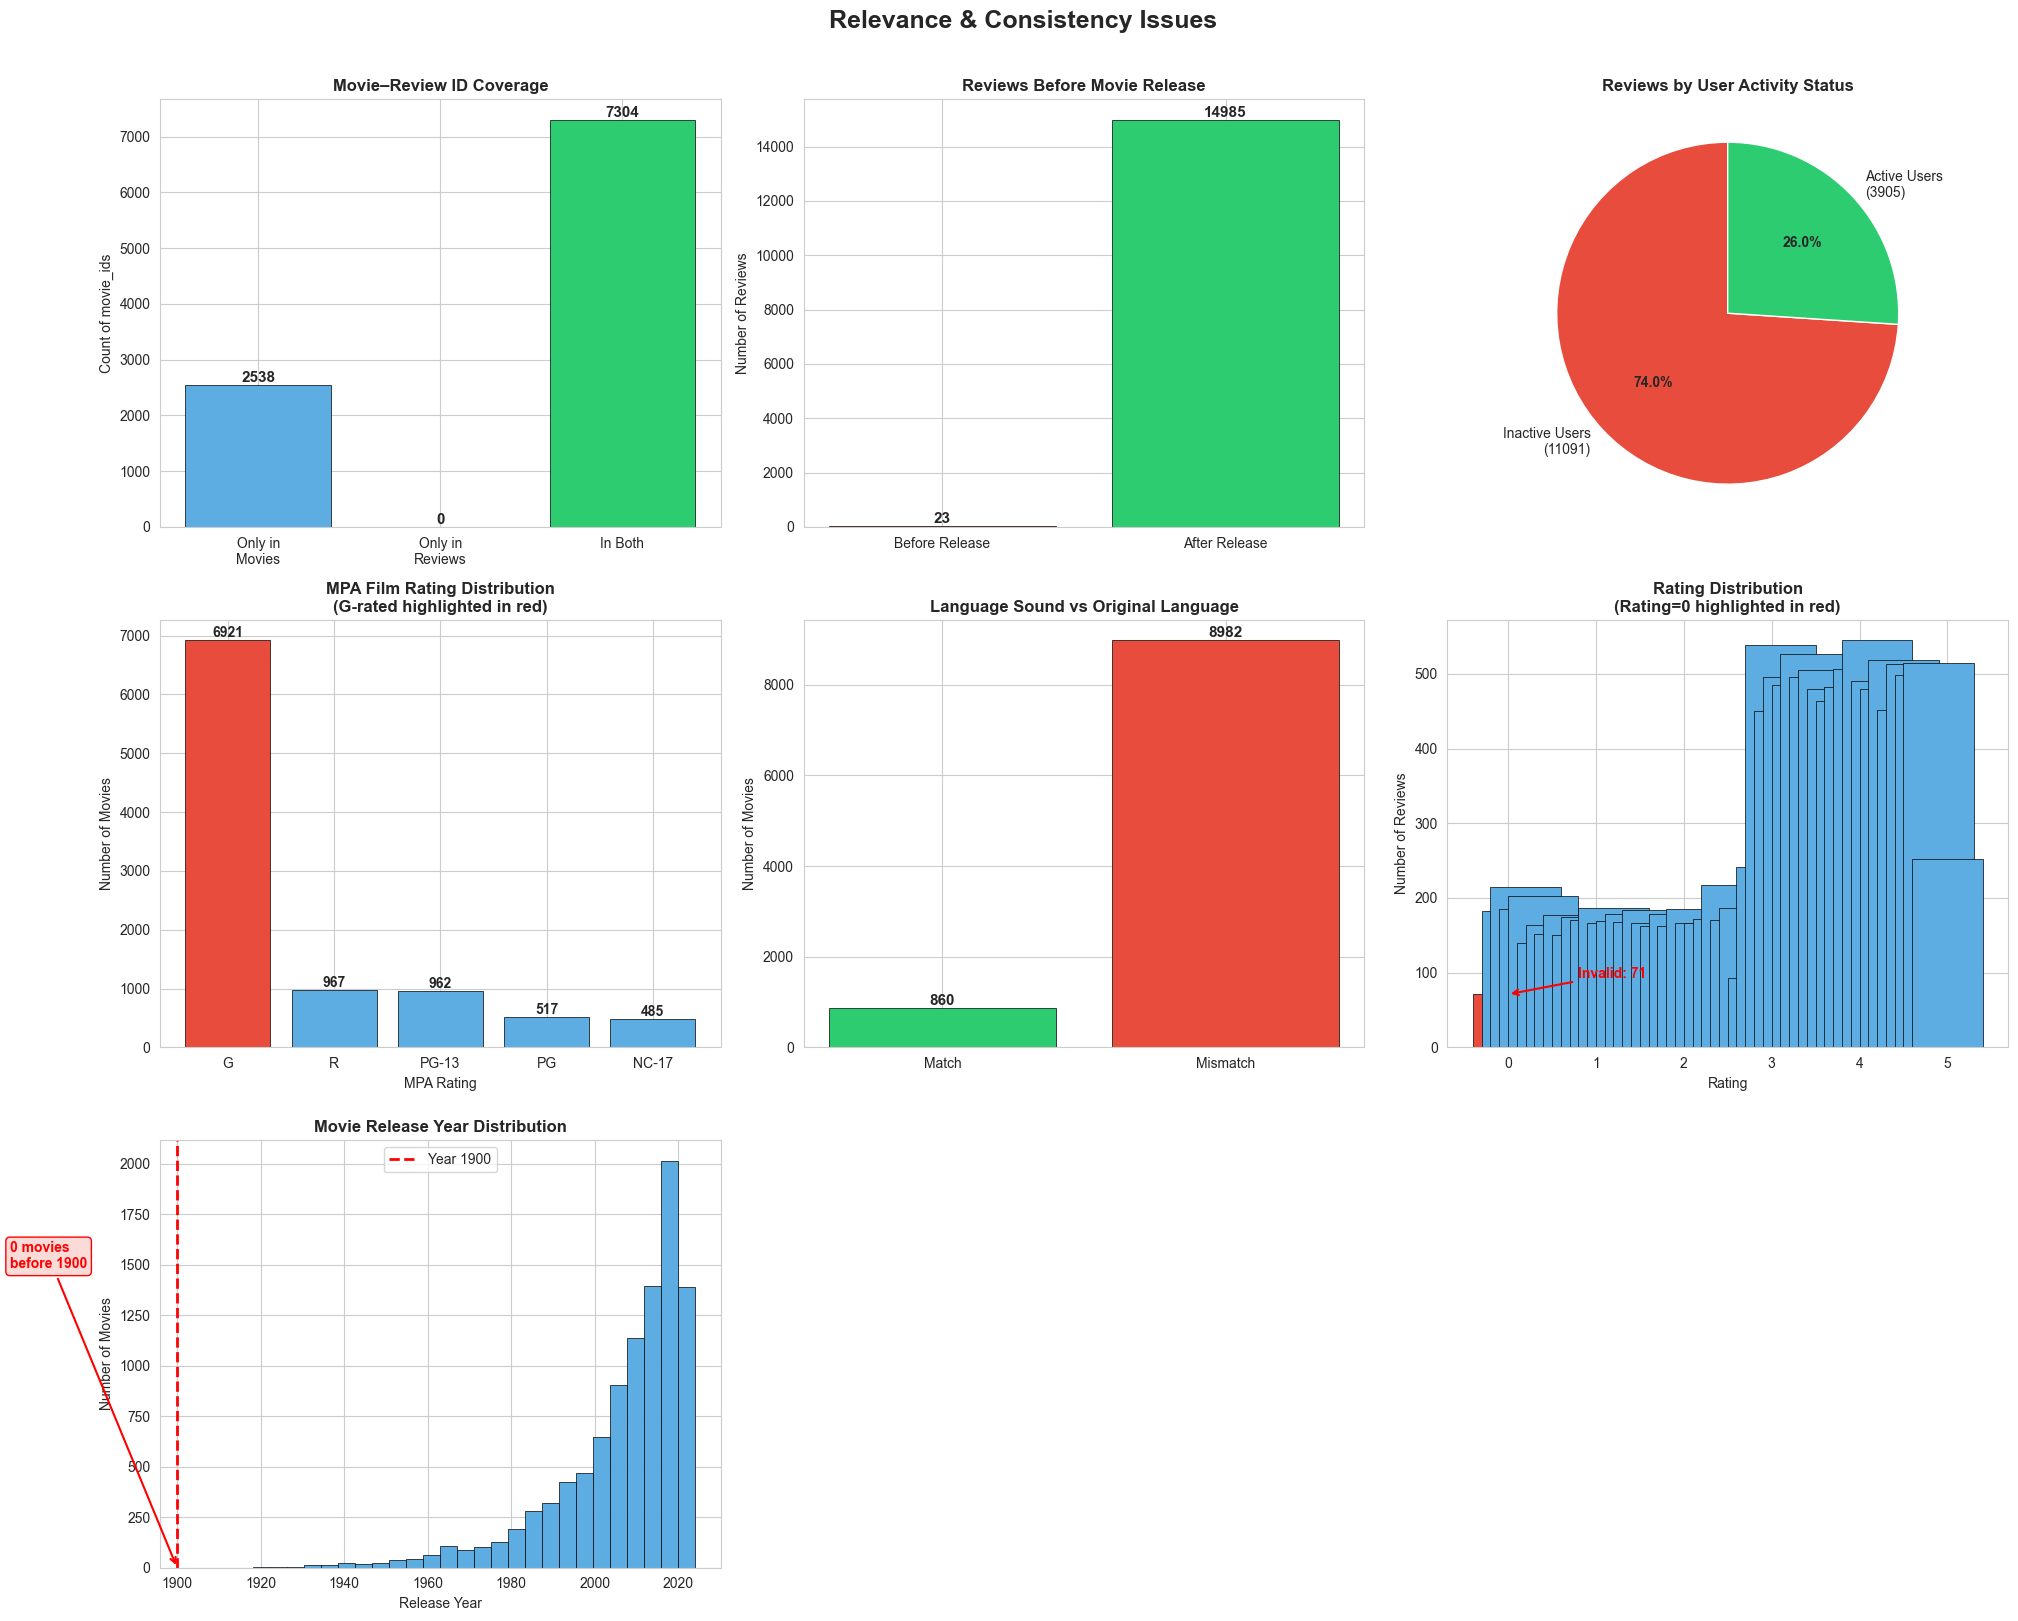

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
fig.suptitle('Relevance & Consistency Issues', fontsize=18, fontweight='bold', y=1.01)

# ── 1. Movie-Review ID Coverage (Relevance) ──
ax = axes[0, 0]
only_movies = len(mov_ids - rev_ids)
only_reviews = len(rev_ids - mov_ids)
in_both = len(mov_ids & rev_ids)
categories = ['Only in\nMovies', 'Only in\nReviews', 'In Both']
values = [only_movies, only_reviews, in_both]
colors_cov = ['#5dade2', '#e74c3c', '#2ecc71']
bars = ax.bar(categories, values, color=colors_cov, edgecolor='black', linewidth=0.5)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(v),
            ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_title('Movie–Review ID Coverage', fontweight='bold')
ax.set_ylabel('Count of movie_ids')

# ── 2. Reviews Before Release (Consistency) ──
ax = axes[0, 1]
valid_reviews = len(m) - len(before)
labels_rel = ['Before Release', 'After Release']
vals_rel = [len(before), valid_reviews]
colors_rel = ['#e74c3c', '#2ecc71']
bars = ax.bar(labels_rel, vals_rel, color=colors_rel, edgecolor='black', linewidth=0.5)
for bar, v in zip(bars, vals_rel):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(v),
            ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_title('Reviews Before Movie Release', fontweight='bold')
ax.set_ylabel('Number of Reviews')

# ── 3. Inactive Users with Reviews (Consistency) ──
ax = axes[0, 2]
active_rev = len(users_reviews_df) - len(inact_reviews)
sizes_iu = [len(inact_reviews), active_rev]
labels_iu = [f'Inactive Users\n({len(inact_reviews)})', f'Active Users\n({active_rev})']
colors_iu = ['#e74c3c', '#2ecc71']
wedges, texts, autotexts = ax.pie(sizes_iu, labels=labels_iu, colors=colors_iu,
                                   autopct='%1.1f%%', startangle=90,
                                   textprops={'fontsize': 10})
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title('Reviews by User Activity Status', fontweight='bold')

# ── 4. MPA Film Rating Distribution (Relevance) ──
ax = axes[1, 0]
mpa_counts = movies_df['MPA_film_rating'].value_counts()
mpa_colors = ['#e74c3c' if idx == 'G' else '#5dade2' for idx in mpa_counts.index]
bars = ax.bar(mpa_counts.index, mpa_counts.values, color=mpa_colors, edgecolor='black', linewidth=0.5)
for bar, v in zip(bars, mpa_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(v),
            ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_title('MPA Film Rating Distribution\n(G-rated highlighted in red)', fontweight='bold')
ax.set_ylabel('Number of Movies')
ax.set_xlabel('MPA Rating')

# ── 5. Language Sound vs Original Language Mismatches (Consistency) ──
ax = axes[1, 1]
lang_compare = movies_df.dropna(subset=['language_sound', 'Original_Language']).copy()
lang_compare['match'] = lang_compare['language_sound'].str.lower() == lang_compare['Original_Language'].str.lower()
match_count = lang_compare['match'].sum()
mismatch_count = len(lang_compare) - match_count
labels_lang = ['Match', 'Mismatch']
vals_lang = [match_count, mismatch_count]
colors_lang = ['#2ecc71', '#e74c3c']
bars = ax.bar(labels_lang, vals_lang, color=colors_lang, edgecolor='black', linewidth=0.5)
for bar, v in zip(bars, vals_lang):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(v),
            ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_title('Language Sound vs Original Language', fontweight='bold')
ax.set_ylabel('Number of Movies')

# ── 6. Rating = 0 Anomaly (Consistency) ──
ax = axes[1, 2]
rating_vals = users_reviews_df['rating'].dropna()
unique_ratings = sorted(rating_vals.unique())
rating_counts = rating_vals.value_counts().sort_index()
bar_colors = ['#e74c3c' if r == 0 else '#5dade2' for r in rating_counts.index]
bars = ax.bar(rating_counts.index, rating_counts.values, color=bar_colors, edgecolor='black', linewidth=0.5)
zero_count = (rating_vals == 0).sum()
if zero_count > 0:
    ax.annotate(f'Invalid: {zero_count}', xy=(0, zero_count), xytext=(0.8, zero_count * 1.3),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
                fontsize=10, color='red', fontweight='bold')
ax.set_title('Rating Distribution\n(Rating=0 highlighted in red)', fontweight='bold')
ax.set_ylabel('Number of Reviews')
ax.set_xlabel('Rating')

# ── 7. Movie Release Year Distribution (Relevance) ──
ax = axes[2, 0]
release_years = movies_df['release_date'].dt.year.dropna()
ax.hist(release_years, bins=30, color='#5dade2', edgecolor='black', linewidth=0.5)
ax.axvline(x=1900, color='red', linestyle='--', linewidth=2, label='Year 1900')
old_count = (release_years < 1900).sum()
ax.annotate(f'{old_count} movies\nbefore 1900', xy=(1900, 0),
            xytext=(1900 - 40, ax.get_ylim()[1] * 0.7),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            fontsize=10, color='red', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#fadbd8', edgecolor='red'))
ax.legend(fontsize=10)
ax.set_title('Movie Release Year Distribution', fontweight='bold')
ax.set_ylabel('Number of Movies')
ax.set_xlabel('Release Year')

# ── Hide unused subplot slots ──
axes[2, 1].axis('off')
axes[2, 2].axis('off')

plt.tight_layout()
plt.show()

# Data Cleaning

Propose appropriate changes to address these issues (the goal is to enhance the quality of the datasets, which will help the AI summarization bot produce more accurate and reliable summaries

**Example**:

Duplicates:
Redundant entries in the data can lead to misleading results during both the analysis and model training. Specifically, if the same review appears multiple times, it can skew sentiment analysis: If a review is repeated multiple times, it could unfairly increase the weight of certain sentiments (positive, neutral, or negative) leading to an unbalanced summary of the movie.
Impact model training: If duplicates are included during training, the model may overfit to these repeated reviews, resulting in biased predictions and inaccurate sentiment understanding.


Proposed change: identify and remove redundant entries from the dataset. To do so we can use pandas

In [39]:
def remove_duplicates(df, subset_columns=None, name="DataFrame"):
    before = len(df)
    if subset_columns:
        df_cleaned = df.drop_duplicates(subset=subset_columns, keep='first')
    else:
        df_cleaned = df.drop_duplicates(keep='first')
    after = len(df_cleaned)
    print(f"{name}: removed {before - after} duplicates ({before} -> {after} rows)")
    return df_cleaned

In [40]:
# Movies: remove 5 exact duplicates
movies_clean = remove_duplicates(movies_df.copy(), name="Movies (exact)")

Movies (exact): removed 5 duplicates (9852 -> 9847 rows)


In [41]:
# Movies: reassign IDs for rows that share movie_id but differ in content
id_dupes = movies_clean[movies_clean.duplicated(subset=['movie_id'], keep=False)].sort_values('movie_id')
print(f"\nMovies with duplicate movie_id but different content: {len(id_dupes)}")
print(id_dupes[['movie_id', 'title', 'release_date']].to_string())

max_id = movies_clean['movie_id'].max()
new_id = max_id + 1
dup_mask = movies_clean.duplicated(subset=['movie_id'], keep='first')
for idx in movies_clean[dup_mask].index:
    movies_clean.loc[idx, 'movie_id'] = new_id
    new_id += 1

print(f"\nReassigned {dup_mask.sum()} duplicate movie_ids with new IDs starting from {max_id + 1}")
print(f"Movies after cleaning: {len(movies_clean)} rows, {movies_clean['movie_id'].nunique()} unique movie_ids")


Movies with duplicate movie_id but different content: 10
      movie_id                    title release_date
1021      1020               Wild Child   2008-08-15
1022      1020               Red Notice   2021-11-04
5594      5592            City Slickers   1991-06-07
5595      5592  The Secret Life of Pets   2016-06-18
5959      5956                Apollo 18   2011-07-20
5960      5956                Capernaum   2018-09-20
6008      6004             First Strike   1996-02-10
6009      6004        A Christmas Carol   1984-10-09
9452      9444                  Spy Cat   2019-04-11
9453      9444           Drive Me Crazy   1999-10-01

Reassigned 5 duplicate movie_ids with new IDs starting from 9859
Movies after cleaning: 9847 rows, 9847 unique movie_ids


In [42]:
# Remove reviews written before movie release date
movies_clean['release_date'] = pd.to_datetime(movies_clean['release_date'], errors='coerce')
reviews_clean = users_reviews_df.copy()
reviews_clean['review_date'] = pd.to_datetime(reviews_clean['review_date'], errors='coerce')

reviews_with_release = reviews_clean.merge(
    movies_clean[['movie_id', 'release_date']], on='movie_id', how='left'
)

before_count = len(reviews_clean)
valid_mask = (
    reviews_with_release['release_date'].isnull() |
    (reviews_with_release['review_date'] >= reviews_with_release['release_date'])
)
reviews_clean = reviews_clean.loc[valid_mask.values].copy()
print(f"Reviews: removed {before_count - len(reviews_clean)} pre-release reviews ({before_count} -> {len(reviews_clean)} rows)")

Reviews: removed 23 pre-release reviews (14996 -> 14973 rows)


In [44]:
# Replace empty strings with NaN across all datasets
def replace_empty_with_null(df, name="DataFrame"):
    replacements = 0
    for col in df.select_dtypes(include=['object']).columns:
        mask = df[col].str.strip() == ''
        count = mask.sum()
        if count > 0:
            df.loc[mask, col] = np.nan
            replacements += count
            print(f"  {name} - '{col}': replaced {count} empty strings with NaN")
    if replacements == 0:
        print(f"  {name}: no empty strings found")
    return df

movies_clean = replace_empty_with_null(movies_clean, "Movies")
users_clean = users_df.copy()
users_clean = replace_empty_with_null(users_clean, "Users")
reviews_clean = replace_empty_with_null(reviews_clean, "Reviews")

print(f"\nMissing values after cleaning:")
print(f"  Movies:  {movies_clean.isnull().sum().sum()} total NaN values")
print(f"  Users:   {users_clean.isnull().sum().sum()} total NaN values")
print(f"  Reviews: {reviews_clean.isnull().sum().sum()} total NaN values")

  Movies: no empty strings found
  Users: no empty strings found
  Reviews: no empty strings found

Missing values after cleaning:
  Movies:  537 total NaN values
  Users:   0 total NaN values
  Reviews: 0 total NaN values


In [90]:
# left only movies with reviews present in sentiment_ai.json
import json

with open('sentiment_ai.json', 'r') as f:
    ai_sentiment_data = json.load(f)

# Get unique movie_ids from sentiment_ai.json
ai_movie_ids = set([item['movie_id'] for item in ai_sentiment_data])
print(f"Movie IDs in sentiment_ai.json: {len(ai_movie_ids)} unique movies")
print(f"Movie ID range: {min(ai_movie_ids)} - {max(ai_movie_ids)}")

movies_reviews_filtered_df = reviews_clean[reviews_clean['movie_id'].isin(ai_movie_ids)].copy()

print(f"Movies represented: {movies_reviews_filtered_df['movie_id'].nunique()} unique movies")

print(f"\nSample of filtered reviews DataFrame:")
print(movies_reviews_filtered_df[['movie_id', 'user_id', 'rating', 'review_date']].head(10))

Movie IDs in sentiment_ai.json: 73 unique movies
Movie ID range: 1 - 90
Movies represented: 69 unique movies

Sample of filtered reviews DataFrame:
     movie_id  user_id  rating review_date
24         58     1797     5.0  2023-04-18
106        14      577     3.5  2023-06-20
236         3      815     3.1  2022-07-10
265         1      184     0.9  2024-04-18
309        23      893     2.9  2023-03-09
434        24       35     4.8  2024-07-12
488        32     1378     1.4  2022-01-29
604        38      155     4.0  2023-10-23
868        14      867     3.6  2023-12-29
998         2     1015     3.3  2023-09-13


# Analyze AI Summaries
## build a list of positive, neutral and negative words
Example:

In [45]:
# import json
import re
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

In [46]:
# Download required NLTK data
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\KarynaOhol1\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\KarynaOhol1\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [52]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\KarynaOhol1\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [53]:
def preprocess_text(text):
    if pd.isna(text) or text == '':
        return []

    text = str(text).lower()
    text = re.sub(r'[^\w\s]', ' ', text)

    # Tokenize
    words = word_tokenize(text)

    # Get English stopwords
    stop_words = set(stopwords.words('english'))

    custom_stopwords = {
        'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 'yours',
        'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', 'her', 'hers',
        'herself', 'it', 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves',
        'what', 'which', 'who', 'whom', 'this', 'that', 'these', 'those', 'am', 'is', 'are',
        'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does',
        'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until',
        'while', 'of', 'at', 'by', 'for', 'with', 'through', 'during', 'before', 'after',
        'above', 'below', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again',
        'further', 'then', 'once', 'movie', 'film', 'watch', 'watched', 'watching', 'see',
        'seen', 'seeing', 'time', 'times', 'really', 'very', 'much', 'many', 'also', 'just',
        'get', 'got', 'getting', 'like', 'would', 'could', 'should', 'may', 'might', 'will',
        'shall', 'can', 'cant', 'cannot', 'wont', 'wouldnt', 'couldnt', 'shouldnt', 'think',
        'thought', 'thinking', 'know', 'knew', 'known', 'knowing', 'way', 'make', 'made',
        'making', 'take', 'took', 'taken', 'taking', 'come', 'came', 'coming', 'give',
        'gave', 'given', 'giving', 'go', 'went', 'going', 'look', 'looked', 'looking'
    }

    stop_words.update(custom_stopwords)

    meaningful_words = [
        word for word in words
        if word not in stop_words
        and len(word) > 2
        and not word.isdigit()
        and word.isalpha()
    ]

    return meaningful_words


In [99]:
def extract_sentiment_words(reviews_df):

    positive_reviews = reviews_df[reviews_df['rating'] >= 4.0]
    neutral_reviews = reviews_df[(reviews_df['rating'] >= 3.0) & (reviews_df['rating'] < 4.0)]
    negative_reviews = reviews_df[reviews_df['rating'] < 3.0]

    print(f"Review categories:")
    print(f"  Positive (rating ≥ 4.0): {len(positive_reviews)} reviews")
    print(f"  Neutral (rating 3.0-3.9): {len(neutral_reviews)} reviews")
    print(f"  Negative (rating < 3.0): {len(negative_reviews)} reviews")

    # Extract words from each category
    positive_words = []
    neutral_words = []
    negative_words = []

    # Process positive reviews
    for review_text in positive_reviews['review_text'].dropna():
        words = preprocess_text(review_text)
        positive_words.extend(words)

    # Process neutral reviews
    for review_text in neutral_reviews['review_text'].dropna():
        words = preprocess_text(review_text)
        neutral_words.extend(words)

    # Process negative reviews
    for review_text in negative_reviews['review_text'].dropna():
        words = preprocess_text(review_text)
        negative_words.extend(words)

    # Count word frequencies in each category
    positive_word_counts = Counter(positive_words)
    neutral_word_counts = Counter(neutral_words)
    negative_word_counts = Counter(negative_words)

    # Get all unique words that appear at least 2 times in any category
    all_words = set()
    for word, count in positive_word_counts.items():
        if count >= 2:
            all_words.add(word)
    for word, count in neutral_word_counts.items():
        if count >= 2:
            all_words.add(word)
    for word, count in negative_word_counts.items():
        if count >= 2:
            all_words.add(word)

    print(f"\nTotal unique words across all categories: {len(all_words)}")

    # Classify words based on their predominant usage
    final_positive_words = []
    final_neutral_words = []
    final_negative_words = []

    classification_stats = {
        'reassigned_to_positive': 0,
        'reassigned_to_neutral': 0,
        'reassigned_to_negative': 0,
        'conflicts_resolved': 0
    }

    for word in all_words:
        pos_count = positive_word_counts.get(word, 0)
        neu_count = neutral_word_counts.get(word, 0)
        neg_count = negative_word_counts.get(word, 0)

        total_count = pos_count + neu_count + neg_count
        if total_count < 2:
            continue

        # Calculate percentages
        pos_pct = pos_count / total_count
        neu_pct = neu_count / total_count
        neg_pct = neg_count / total_count

        # Classify based on predominant usage (>50% threshold)
        max_pct = max(pos_pct, neu_pct, neg_pct)

        if pos_pct == max_pct and pos_pct > 0.5:
            final_positive_words.append(word)
            if neu_count > 0 or neg_count > 0:
                classification_stats['reassigned_to_positive'] += 1
        elif neg_pct == max_pct and neg_pct > 0.5:
            final_negative_words.append(word)
            if pos_count > 0 or neu_count > 0:
                classification_stats['reassigned_to_negative'] += 1
        else:
            # If no category has >50% or neutral is dominant, classify as neutral
            final_neutral_words.append(word)
            if pos_count > 0 or neg_count > 0:
                classification_stats['reassigned_to_neutral'] += 1

        # Track conflicts resolved
        if (pos_count > 0 and neu_count > 0) or (pos_count > 0 and neg_count > 0) or (neu_count > 0 and neg_count > 0):
            classification_stats['conflicts_resolved'] += 1

    print(f"\nImproved word classification results:")
    print(f"  Final positive words: {len(final_positive_words)} unique words")
    print(f"  Final neutral words: {len(final_neutral_words)} unique words")
    print(f"  Final negative words: {len(final_negative_words)} unique words")

    print(f"\nClassification improvements:")
    print(f"  Words reassigned to positive: {classification_stats['reassigned_to_positive']}")
    print(f"  Words reassigned to neutral: {classification_stats['reassigned_to_neutral']}")
    print(f"  Words reassigned to negative: {classification_stats['reassigned_to_negative']}")
    print(f"  Cross-category conflicts resolved: {classification_stats['conflicts_resolved']}")

    return {
        'positive_words': final_positive_words,
        'neutral_words': final_neutral_words,
        'negative_words': final_negative_words,
        'positive_counts': positive_word_counts,
        'neutral_counts': neutral_word_counts,
        'negative_counts': negative_word_counts,
        'classification_stats': classification_stats
    }

In [100]:
# sentiment_words_data = extract_sentiment_words(reviews_clean)
sentiment_words_data = extract_sentiment_words(movies_reviews_filtered_df)

Review categories:
  Positive (rating ≥ 4.0): 47 reviews
  Neutral (rating 3.0-3.9): 54 reviews
  Negative (rating < 3.0): 42 reviews

Total unique words across all categories: 90

Improved word classification results:
  Final positive words: 33 unique words
  Final neutral words: 38 unique words
  Final negative words: 19 unique words

Classification improvements:
  Words reassigned to positive: 7
  Words reassigned to neutral: 12
  Words reassigned to negative: 1
  Cross-category conflicts resolved: 20


In [101]:
positive_words = sentiment_words_data['positive_words']
print(positive_words)

['finish', 'fantastic', 'second', 'recommend', 'enjoyed', 'experience', 'every', 'enjoy', 'romance', 'unforgettable', 'amazing', 'highly', 'beginning', 'drama', 'start', 'miss', 'perfect', 'loved', 'action', 'good', 'till', 'end', 'masterpiece', 'incredible', 'keep', 'hooked', 'glad', 'true', 'wonderful', 'must', 'truly', 'simply', 'best']


In [102]:
neutral_words = sentiment_words_data['neutral_words']
print(neutral_words)

['particularly', 'mind', 'one', 'hate', 'impressed', 'stood', 'alright', 'either', 'blowing', 'write', 'light', 'terrible', 'better', 'enough', 'enjoyable', 'repeat', 'overall', 'mediocre', 'impress', 'okay', 'great', 'watchable', 'feel', 'average', 'sold', 'totally', 'special', 'home', 'anything', 'nothing', 'strongly', 'something', 'fine', 'say', 'viewing', 'worth', 'storyline', 'call']


In [103]:
negative_words = sentiment_words_data['negative_words']
print(negative_words)

['found', 'regret', 'acting', 'disappointing', 'plot', 'letdown', 'real', 'poor', 'whole', 'frustrated', 'boring', 'anyone', 'predictable', 'total', 'disappointed', 'disappointment', 'waste', 'bad', 'felt']


## count how many positive, neutral and negative words there are for each movie

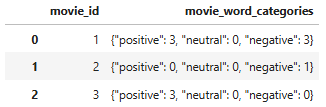

In [114]:
def count_sentiment_words_per_movie(reviews_df, positive_words, neutral_words, negative_words):
    movie_sentiment_counts = []
    unique_movies = reviews_df['movie_id'].unique()

    for movie_id in unique_movies:
        movie_reviews = reviews_df[reviews_df['movie_id'] == movie_id]
        all_review_text = ' '.join(movie_reviews['review_text'].dropna().astype(str))
        movie_words = preprocess_text(all_review_text)

        positive_count = sum(1 for word in movie_words if word in positive_words)
        neutral_count = sum(1 for word in movie_words if word in neutral_words)
        negative_count = sum(1 for word in movie_words if word in negative_words)

        movie_sentiment_counts.append({
            'movie_id': movie_id,
            'positive_count': positive_count,
            'neutral_count': neutral_count,
            'negative_count': negative_count,
            'rewiew_text': all_review_text
        })
    sentiment_counts_df = pd.DataFrame(movie_sentiment_counts)
    sentiment_counts_df = sentiment_counts_df.sort_values('movie_id')

    return sentiment_counts_df


In [117]:
# movie_sentiment_df = count_sentiment_words_per_movie(reviews_clean, positive_words, neutral_words, negative_words)
movie_sentiment_df = count_sentiment_words_per_movie(movies_reviews_filtered_df, positive_words, neutral_words, negative_words)

print(f"Total movies: {len(movie_sentiment_df)}")
print("\nFirst 10 movies:")
print(movie_sentiment_df[['movie_id','positive_count','neutral_count', 'negative_count']].head(10).to_string(index=False))

Total movies: 69

First 10 movies:
 movie_id  positive_count  neutral_count  negative_count
        1               7              0               4
        2               0              5               2
        3               2              7               0
        4               4              1               0
        5               1             14               3
        6               0              3               0
        7               0              0               5
        8               0              1               2
        9               0              6               0
       10               1              4               3


## identify dominant category (category with the highest count) according to following rules and set sentiment as expected sentiment column:

**Positive is Dominant**
If the number of positive words is greater apply formula for sentiment: 

neutral - 1 + negative < positive, classify as Positive, otherwise, classify as Neutral

**Neutral is Dominant**
If the number of neutral words is greater classify as Neutral

**Negative is Dominant**
If the number of negative words is greater apply formula for sentiment: 

positive + neutral ≥ negative, classify as Neutral, otherwise, classify as Negative

**No Dominant Category** 
If there is no single category with the highest count classify the sentiment as Neutral

**Example**: 
For movie_id = 1, we have: 
Positive words: 3
Neutral words: 0
Negative words: 3

Since Positive and Negative have the same count and neither is greater than the others → There is no dominant category. 
According to the rules, if there is no dominant category, the sentiment is classified as **Neutral**.

as result we expect the following: 

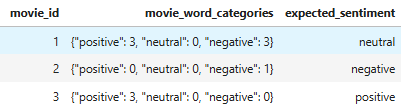

In [64]:
def determine_expected_sentiment(positive_count, neutral_count, negative_count):

    max_count = max(positive_count, neutral_count, negative_count)

    dominant_categories = []
    if positive_count == max_count:
        dominant_categories.append('positive')
    if neutral_count == max_count:
        dominant_categories.append('neutral')
    if negative_count == max_count:
        dominant_categories.append('negative')

    if len(dominant_categories) > 1:
        return 'neutral'

    dominant = dominant_categories[0]

    if dominant == 'positive':
        if (neutral_count - 1 + negative_count) < positive_count:
            return 'positive'
        else:
            return 'neutral'

    elif dominant == 'neutral':
        return 'neutral'

    elif dominant == 'negative':
        if (positive_count + neutral_count) >= negative_count:
            return 'neutral'
        else:
            return 'negative'

    return 'neutral' #default

In [120]:
# Apply sentiment classification rules
movie_sentiment_df['expected_sentiment'] = movie_sentiment_df.apply(
    lambda row: determine_expected_sentiment(
        row['positive_count'],
        row['neutral_count'],
        row['negative_count']
    ), axis=1
)
print(movie_sentiment_df['expected_sentiment'])

3     positive
8      neutral
2      neutral
33    positive
43     neutral
        ...   
11     neutral
55    positive
35    negative
37     neutral
52     neutral
Name: expected_sentiment, Length: 69, dtype: str


In [121]:
print(movie_sentiment_df.head(3))

   movie_id  positive_count  neutral_count  negative_count  \
3         1               7              0               4   
8         2               0              5               2   
2         3               2              7               0   

                                         rewiew_text expected_sentiment  
3  It felt like a predictable experience. The mov...           positive  
8  The film was average, not particularly great, ...            neutral  
2  It’s alright, watchable but not worth a repeat...            neutral  


## Compare calculated expected sentiment with AI sentiment

**Example**

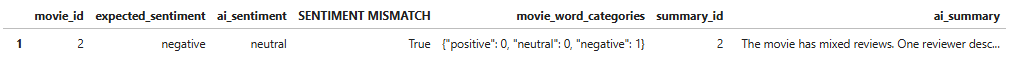

In [71]:
# Load AI sentiment data
with open('sentiment_ai.json', 'r') as f:
    ai_sentiment_data = json.load(f)
ai_sentiment_df = pd.DataFrame(ai_sentiment_data)

In [77]:
print(ai_sentiment_df.head(3))

   summary_id  movie_id                                         ai_summary  \
0           1         1  The movie is divisive. Opinions are divided. O...   
1           2         2  The movie has mixed reviews. One reviewer desc...   
2           3         3  The movie has mixed reviews. One reviewer foun...   

  ai_sentiment  
0      neutral  
1      neutral  
2      neutral  


In [123]:
comparison_df = movie_sentiment_df.merge(
    ai_sentiment_df[['movie_id', 'ai_sentiment']],
    on='movie_id',
    how='left'
)
comparison_df['sentiment_match'] = comparison_df['expected_sentiment'] == comparison_df['ai_sentiment']

In [124]:
print(comparison_df.head(3))

   movie_id  positive_count  neutral_count  negative_count  \
0         1               7              0               4   
1         2               0              5               2   
2         3               2              7               0   

                                         rewiew_text expected_sentiment  \
0  It felt like a predictable experience. The mov...           positive   
1  The film was average, not particularly great, ...            neutral   
2  It’s alright, watchable but not worth a repeat...            neutral   

  ai_sentiment  sentiment_match  
0      neutral            False  
1      neutral             True  
2      neutral             True  


In [125]:
total_movies = len(comparison_df)
matches = comparison_df['sentiment_match'].sum()
match_percentage = (matches / total_movies * 100) if total_movies > 0 else 0

print(f"Total movies compared: {total_movies}")
print(f"Sentiment matches: {matches}")
print(f"Sentiment mismatches: {total_movies - matches}")
print(f"Match accuracy: {match_percentage:.1f}%")

Total movies compared: 69
Sentiment matches: 50
Sentiment mismatches: 19
Match accuracy: 72.5%


In [127]:
mismatches_df = comparison_df[~comparison_df['sentiment_match']].copy()
# mismatch_display_cols = ['movie_id', 'positive_count', 'neutral_count', 'negative_count', 'expected_sentiment', 'ai_sentiment','rewiew_text']
mismatch_display_cols = ['movie_id', 'expected_sentiment', 'ai_sentiment','rewiew_text']
print(mismatches_df[mismatch_display_cols].to_string(index=False))

 movie_id expected_sentiment ai_sentiment                                                                                                                                                                                                                                                                                                                           rewiew_text
        1           positive      neutral                                                                                                                                                                        It felt like a predictable experience. The movie was disappointed and boring. This film was must-see from beginning to end. Truly an unforgettable experience!
        6            neutral     positive                                                                                                                                                                                                                               

### Review the mismatches 

between the expected_sentiment (calculated based on user reviews) and the ai_sentiment (generated by the AI summary bot).

Then, reflect on why these mismatches may occur and share 3 possible reasons

In [130]:
mismatches_df = comparison_df[~comparison_df['sentiment_match']].copy()
mismatch_display_cols = ['movie_id', 'positive_count', 'neutral_count', 'negative_count', 'expected_sentiment', 'ai_sentiment']
# mismatch_display_cols = ['movie_id', 'expected_sentiment', 'ai_sentiment','rewiew_text']
print(mismatches_df[mismatch_display_cols].to_string(index=False))

 movie_id  positive_count  neutral_count  negative_count expected_sentiment ai_sentiment
        1               7              0               4           positive      neutral
        6               0              3               0            neutral     positive
        8               0              1               2           negative     positive
       20               6              7               0            neutral     positive
       27               3              1               2           positive      neutral
       44               5              1               3           positive      neutral
       47               4              5               0            neutral     positive
       48               4              1               3           positive     negative
       53               7              0               5           positive      neutral
       54               0              4               6           negative      neutral
       55            

In [133]:
mismatches_df = comparison_df[~comparison_df['sentiment_match']].copy()
# mismatch_display_cols = ['movie_id', 'positive_count', 'neutral_count', 'negative_count', 'expected_sentiment', 'ai_sentiment','rewiew_text']
mismatch_display_cols = ['movie_id', 'expected_sentiment', 'ai_sentiment','rewiew_text']
print(mismatches_df[mismatch_display_cols].to_string(index=False))

 movie_id expected_sentiment ai_sentiment                                                                                                                                                                                                                                                                                                                           rewiew_text
        1           positive      neutral                                                                                                                                                                        It felt like a predictable experience. The movie was disappointed and boring. This film was must-see from beginning to end. Truly an unforgettable experience!
        6            neutral     positive                                                                                                                                                                                                                               

In [138]:
# expected_sentiment - positive;ai_sentiment - neutral
#  just words number may be not enough,with context AI set a - neutral seems as a correct answer
movie_1_reviews = movies_reviews_filtered_df[movies_reviews_filtered_df['movie_id'] == 1].copy()
print(movie_1_reviews[['review_text', 'rating']].to_string(index=False))

                                                                     review_text  rating
   It felt like a predictable experience. The movie was disappointed and boring.     0.9
This film was must-see from beginning to end. Truly an unforgettable experience!     4.6


In [141]:
# AI maybe got confused with some positive words in the reviews, but overall the sentiment is neutral.
movie_6_reviews = movies_reviews_filtered_df[movies_reviews_filtered_df['movie_id'] == 6].copy()
print(movie_6_reviews[['review_text', 'rating']].to_string(index=False))

                                                   review_text  rating
The movie was alright, it did not impress me, but it was fine.     3.5


In [139]:
# we definitely see that there are negative context but AI mark as positive. Maybe got confused with some positive words in the reviews, but overall the sentiment is negative.
movie_8_reviews = movies_reviews_filtered_df[movies_reviews_filtered_df['movie_id'] == 8].copy()
print(movie_8_reviews[['review_text', 'rating']].to_string(index=False))

                                                                  review_text  rating
This movie is great to waste time! Suggest it to annoy someone. Disappointing     0.5


In generall our  rule-based approach counts individual sentiment words without understanding context, while AI models comprehend semantic meaning and relationships. - that why we can get incorrect interpretations. Also, we don't  take to a count a weighs of words,like   "incredible" more heavily than "good", we treat words only by categories.It creates some biases where we have a lot of oposit reviews but set as a positive final mark.

But our approach helped us identify some reviews with clarly not correct mark seted by AI, Maybe got confused with some positive words,semantic, but overall the sentiment is negative.